In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from arch import arch_model

In [2]:
data = pd.read_csv("../data/features_target.csv")

data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])
data.rename(columns = {'Unnamed: 0':'Date'}, inplace=True) 
data.set_index('Date', inplace = True)

returns = 100 * data['SP500'].pct_change().dropna()
returns = returns.drop(returns[returns == 0].index)

vol = returns.rolling(window = 30, min_periods = 30).std().dropna()

In [3]:
split_date = '2018-01-01'

train = vol[vol.index < split_date].copy()
test = vol[vol.index >= split_date].copy()

In [4]:
train

Date
2010-08-19    1.191692
2010-08-20    1.186285
2010-08-23    1.188293
2010-08-24    1.177692
2010-08-25    1.180504
                ...   
2017-12-22    0.419970
2017-12-26    0.411927
2017-12-27    0.410079
2017-12-28    0.410162
2017-12-29    0.422083
Name: SP500, Length: 1804, dtype: float64

In [9]:
from ctgan import CTGAN

model = CTGAN()
model.fit(pd.DataFrame(train))
synthetic = model.sample(1804)

In [11]:
synthetic.index = train.index
train = synthetic["SP500"]
train

Date
2010-08-19    0.893538
2010-08-20    0.748515
2010-08-23    0.776970
2010-08-24    0.628417
2010-08-25    0.900422
                ...   
2017-12-22    0.561273
2017-12-26    0.666413
2017-12-27    0.114291
2017-12-28    0.899813
2017-12-29    0.610425
Name: SP500, Length: 1804, dtype: float64

In [12]:
garch = arch_model(train, dist="ged", vol = 'GARCH', p=1, q=1)
garch_fit = garch.fit(disp='off')
garch_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Constant Mean - GARCH Model Results                            
==========================================================================================
Dep. Variable:                              SP500   R-squared:                       0.000
Mean Model:                         Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                  GARCH   Log-Likelihood:               -527.512
Distribution:      Generalized Error Distribution   AIC:                           1065.02
Method:                        Maximum Likelihood   BIC:                           1092.51
                                                    No. Observations:                 1804
Date:                            Wed, Apr 22 2026   Df Residuals:                     1803
Time:                                    00:21:26   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.7470  1.112e-02     67.179      0.000 [  0.725,  0.769]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.1149  3.061e-02      3.754  1.742e-04    [5.490e-02,  0.175]
alpha[1]   7.0188e-03  7.774e-03      0.903      0.367 [-8.218e-03,2.226e-02]
beta[1]    6.4195e-16      0.245  2.623e-15      1.000      [ -0.480,  0.480]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             1.1150  5.441e-02     20.492  2.533e-93 [  1.008,  1.222]
========================================================================

Covariance estimator: robust
"""

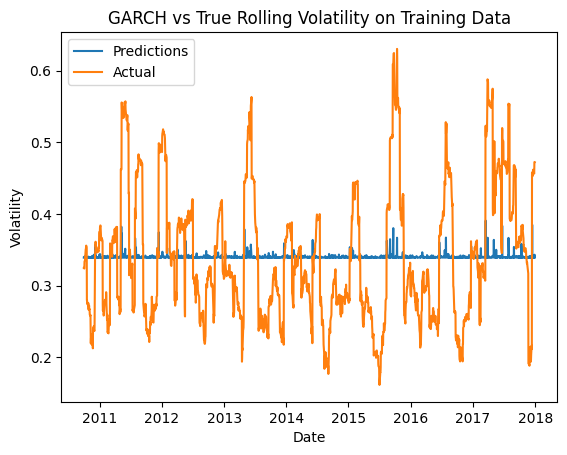

In [13]:
rvol = abs(train.rolling(window=30, min_periods=30).std().dropna())

combined = pd.concat([pd.DataFrame(garch_fit.conditional_volatility), rvol.dropna()], axis=1).dropna()

plt.plot(combined)
plt.title('GARCH vs True Rolling Volatility on Training Data')
plt.legend(['Predictions', 'Actual'])
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

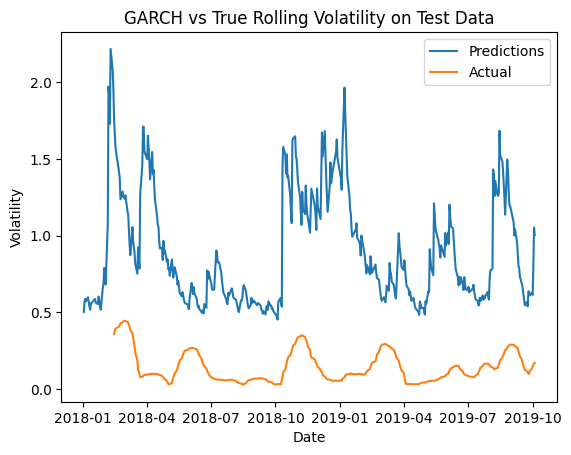

In [14]:
tsize = len(test)
preds = []
for i in range(tsize):
    train = returns[:(i-tsize)]
    garch = arch_model(train, dist = "ged", vol = 'GARCH', p=1, q=1)
    garch_fit = garch.fit(disp = 'off')
    pred = garch_fit.forecast(horizon=1, reindex = False)
    preds.append(np.sqrt(pred.variance.values[-1,:][0]))
    
preds = pd.Series(preds, returns.dropna().index[-tsize:])
predicted = plt.plot(preds)
rvol = abs(test.rolling(window=30, min_periods=30).std().dropna())
real = plt.plot(rvol)
plt.title('GARCH vs True Rolling Volatility on Test Data')
plt.legend(['Predictions', 'Actual'])
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [15]:
preds = preds[29:]
mse = mean_squared_error(rvol, preds)
rmse = math.sqrt(mse)
print("Mean Squared Error for our Predictions: " + str(mse))
print("Root Mean Squared Error for our Predictions: " + str(rmse))

Mean Squared Error for our Predictions: 0.6741216842162708
Root Mean Squared Error for our Predictions: 0.8210491362983526
